
EDA-1: Year-wise Weighted Average Rating and Rating Dispersion



Saved per-year WAR & weighted std to: /content/war_and_weighted_std_by_year.csv

Preview:
      Year  Total_Exposure_Crores       WAR  Weighted_STD
0   Year 1           30165.018917  4.439431      2.335375
1   Year 2           30747.710017  4.601716      2.289079
2   Year 3           31564.467885  4.504549      2.262436
3   Year 4           30067.135945  4.530134      2.303486
4   Year 5           30904.608740  4.497833      2.270640
5   Year 6           30377.129914  4.559747      2.300176
6   Year 7           30777.225541  4.590468      2.277166
7   Year 8           31175.648545  4.556427      2.330482
8   Year 9           30693.119742  4.501189      2.253065
9  Year 10           30829.708922  4.554664      2.293742
Saved chart to: /content/war_and_weighted_std_by_year.png


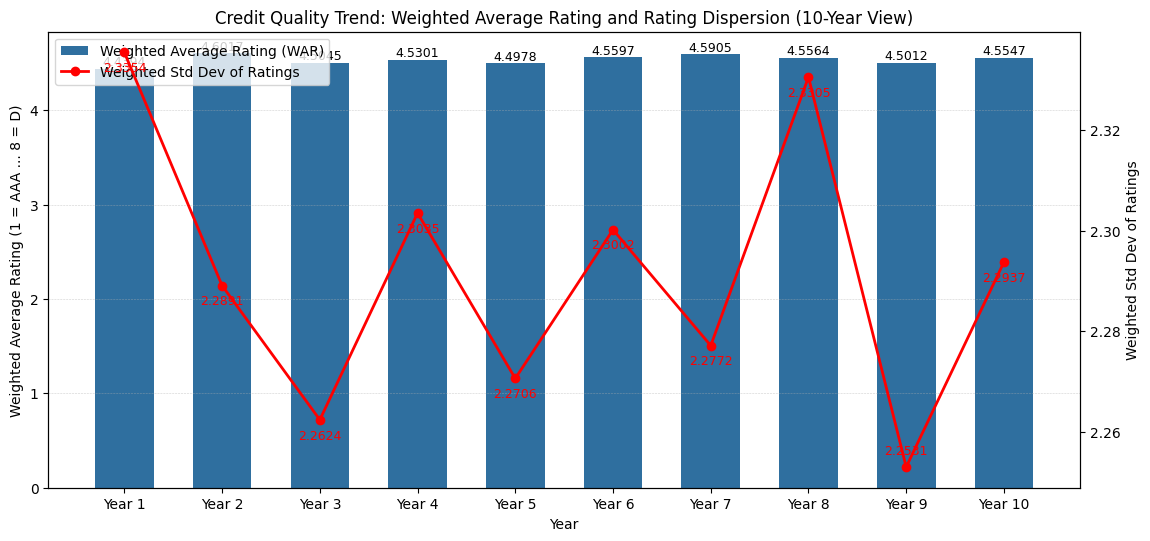

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

XLSX = "/content/FRAM-Book.xlsx"
HEADER_ROW = 0
OUT_CSV = "war_and_weighted_std_by_year.csv"
OUT_PNG = "war_and_weighted_std_by_year.png"

RATING_TO_SCORE = {"AAA": 1, "AA": 2, "A": 3, "BBB": 4, "BB": 5, "B": 6, "C": 7, "D": 8}

def weighted_stats(values, weights):
    weights = np.array(weights, dtype=float)
    values = np.array(values, dtype=float)
    wsum = weights.sum()
    if wsum == 0:
        return np.nan, np.nan
    wmean = (weights * values).sum() / wsum
    variance = (weights * (values - wmean) ** 2).sum() / wsum
    wstd = np.sqrt(variance)
    return wmean, wstd

df = pd.read_excel(XLSX, header=HEADER_ROW)

rating_cols = [f"Year {i}_Ratings" for i in range(1, 11)]
amount_cols = [f"Year {i}_Amount in Rs Crore" for i in range(1, 11)]

results = []
for i in range(1, 11):
    rcol = rating_cols[i-1]
    acol = amount_cols[i-1]
    if rcol not in df.columns or acol not in df.columns:
        continue
    amt = pd.to_numeric(df[acol], errors="coerce")
    rating_clean = df[rcol].astype(str).str.strip().str.upper()
    rating_score = rating_clean.map(RATING_TO_SCORE)
    mask = amt.notna() & rating_score.notna()
    vals = rating_score[mask].values
    wts = amt[mask].values
    wmean, wstd = weighted_stats(vals, wts)
    total_exposure = wts.sum()
    results.append({
        "Year": f"Year {i}",
        "Total_Exposure_Crores": total_exposure,
        "WAR": wmean,
        "Weighted_STD": wstd
    })

df_year = pd.DataFrame(results)

df_year.to_csv(OUT_CSV, index=False)
print(f"Saved per-year WAR & weighted std to: {os.path.abspath(OUT_CSV)}")
print("\nPreview:")
print(df_year)

years_labels = df_year["Year"].astype(str).tolist()
wars = df_year["WAR"].values
wstds = df_year["Weighted_STD"].values

fig, ax1 = plt.subplots(figsize=(12,6))

bars = ax1.bar(range(len(years_labels)), wars, width=0.6, label="Weighted Average Rating (WAR)", color="#2f6f9f")
ax1.set_xlabel("Year")
ax1.set_ylabel("Weighted Average Rating (1 = AAA ... 8 = D)")
ax1.set_xticks(range(len(years_labels)))
ax1.set_xticklabels(years_labels)

war_range = max(wars) - min(wars) if len(wars) > 1 else max(wars) if len(wars)==1 else 1
y_offset_bar = 0.02 * (war_range if war_range>0 else 1)
for i, rect in enumerate(bars):
    h = rect.get_height()
    if not np.isnan(h):
        ax1.text(rect.get_x() + rect.get_width() / 2,
                 h + y_offset_bar,
                 f"{h:.4f}",
                 ha='center', va='bottom', fontsize=9, color='black')

ax2 = ax1.twinx()
ax2.plot(range(len(years_labels)), wstds, color="red", marker="o", linewidth=2, label="Weighted Std Dev of Ratings")
ax2.set_ylabel("Weighted Std Dev of Ratings")

ymin2, ymax2 = ax2.get_ylim()
yrange2 = ymax2 - ymin2 if (ymax2 - ymin2) != 0 else 1
pad = 0.03 * yrange2
for i, v in enumerate(wstds):
    if np.isnan(v):
        continue
    y_text = v - 0.02 * yrange2
    va = "top"
    if y_text < (ymin2 + pad):
        y_text = v + 0.02 * yrange2
        va = "bottom"
    if y_text > (ymax2 - pad):
        y_text = ymax2 - pad
        va = "top" if y_text <= v else "bottom"
    ax2.text(i, y_text, f"{v:.4f}", ha='center', va=va, fontsize=9, color='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.yaxis.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
plt.title("Credit Quality Trend: Weighted Average Rating and Rating Dispersion (10-Year View)")

plt.subplots_adjust(top=0.88, bottom=0.12, left=0.07, right=0.93)

plt.savefig(OUT_PNG, dpi=300, bbox_inches='tight')
print(f"Saved chart to: {os.path.abspath(OUT_PNG)}")
plt.show()


EDA-2: Year-wise Exposure vs Weighted Average Rating

Grand total exposure (crores) read = 307,301.774168
All rating labels mapped to numeric scores.
Saved per-year exposure & WAR to: /content/exposure_and_war_by_year.csv
      Year  Total_Exposure_Crores       WAR
0   Year 1           30165.018917  4.439431
1   Year 2           30747.710017  4.601716
2   Year 3           31564.467885  4.504549
3   Year 4           30067.135945  4.530134
4   Year 5           30904.608740  4.497833
5   Year 6           30377.129914  4.559747
6   Year 7           30777.225541  4.590468
7   Year 8           31175.648545  4.556427
8   Year 9           30693.119742  4.501189
9  Year 10           30829.708922  4.554664
Saved plot to: /content/exposure_and_war_by_year.png


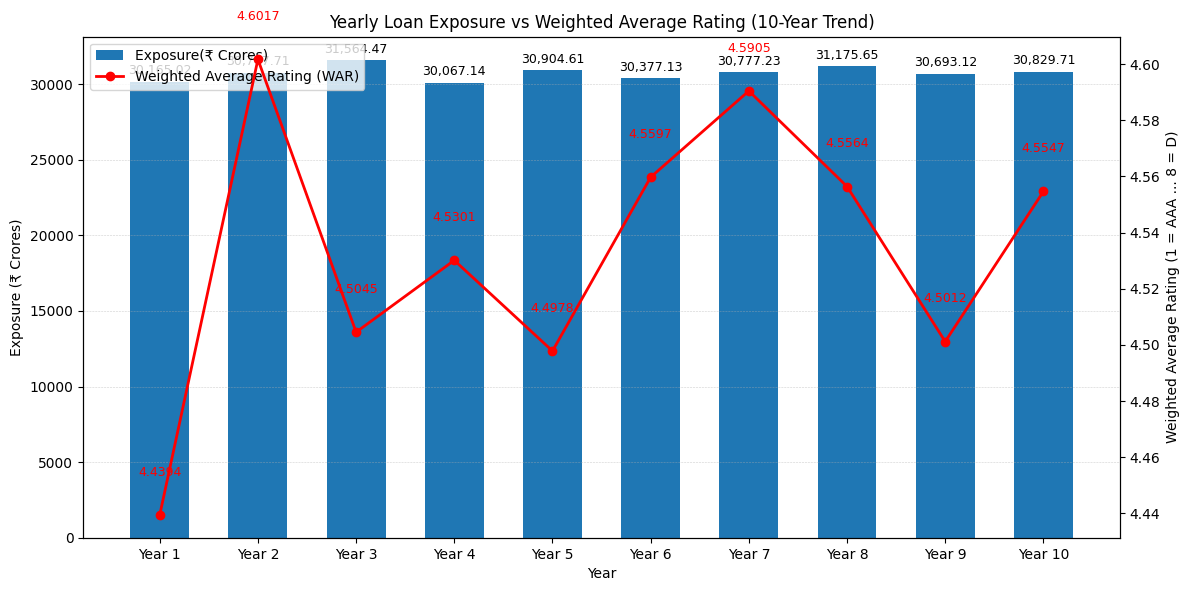

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

XLSX = "/content/FRAM-Book.xlsx"
HEADER_ROW = 0
OUT_CSV = "exposure_and_war_by_year.csv"
OUT_PNG = "exposure_and_war_by_year.png"

RATING_TO_SCORE = {"AAA": 1, "AA": 2, "A": 3, "BBB": 4, "BB": 5, "B": 6, "C": 7, "D": 8}

def year_sort_key(s):
    try:
        return int(''.join(ch for ch in str(s) if ch.isdigit()))
    except:
        return str(s)

df = pd.read_excel(XLSX, header=HEADER_ROW)

amount_cols = [f"Year {i}_Amount in Rs Crore" for i in range(1, 11)]
rating_cols = [f"Year {i}_Ratings" for i in range(1, 11)]

amount_df = df[amount_cols].copy()
rating_df = df[rating_cols].copy()

amount_df.columns = [f"Year {i}" for i in range(1, 11)]
rating_df.columns = [f"Year {i}" for i in range(1, 11)]

amount_long = amount_df.reset_index().melt(id_vars="index", var_name="Year", value_name="Amount")
amount_long = amount_long.rename(columns={"index": "borrower_id"})

rating_long = rating_df.reset_index().melt(id_vars="index", var_name="Year", value_name="Rating")
rating_long = rating_long.rename(columns={"index": "borrower_id"})

merged = pd.merge(amount_long, rating_long, on=["borrower_id", "Year"], how="inner")

merged["Amount"] = pd.to_numeric(merged["Amount"], errors="coerce")
merged["Rating_clean"] = merged["Rating"].astype(str).str.strip().str.upper().replace({"NAN": np.nan})

merged["Rating_score"] = merged["Rating_clean"].map(RATING_TO_SCORE)

merged = merged[merged["Amount"].notna()].copy()

grand_total_exposure = merged["Amount"].sum()
num_unmapped_ratings = merged["Rating_score"].isna().sum()
unique_unmapped = merged.loc[merged["Rating_score"].isna(), "Rating_clean"].value_counts().head(20)

print(f"Grand total exposure (crores) read = {grand_total_exposure:,.6f}")
if num_unmapped_ratings > 0:
    print(f"Warning: {num_unmapped_ratings} cells have rating labels that were not mapped to scores.")
    print("Top unmapped rating raw values (sample):")
    print(unique_unmapped.to_string())
else:
    print("All rating labels mapped to numeric scores.")

merged["Numerator"] = merged["Amount"] * merged["Rating_score"]

exposure_by_year = merged.groupby("Year", as_index=False)["Amount"].sum().rename(columns={"Amount": "Total_Exposure_Crores"})
numerator_by_year = merged.groupby("Year", as_index=False)["Numerator"].sum().rename(columns={"Numerator": "Weighted_Sum"})
df_year = pd.merge(exposure_by_year, numerator_by_year, on="Year", how="outer").fillna(0)

df_year["WAR"] = df_year.apply(lambda r: (r["Weighted_Sum"] / r["Total_Exposure_Crores"]) if r["Total_Exposure_Crores"] != 0 else np.nan, axis=1)

df_year["__sort_key"] = df_year["Year"].apply(year_sort_key)
df_year = df_year.sort_values("__sort_key").drop(columns="__sort_key").reset_index(drop=True)

df_out = df_year[["Year", "Total_Exposure_Crores", "WAR"]].copy()
df_out.to_csv(OUT_CSV, index=False)
print(f"Saved per-year exposure & WAR to: {os.path.abspath(OUT_CSV)}")
print(df_out)

years = df_out["Year"].astype(str).tolist()
exposures = df_out["Total_Exposure_Crores"].values
wars = df_out["WAR"].values

fig, ax1 = plt.subplots(figsize=(12,6))

bars = ax1.bar(range(len(years)), exposures, width=0.6, label="Exposure(₹ Crores)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Exposure (₹ Crores)")
ax1.set_xticks(range(len(years)))
ax1.set_xticklabels(years, rotation=0)

for i, rect in enumerate(bars):
    h = rect.get_height()
    ax1.text(rect.get_x() + rect.get_width()/2, h + 0.01*max(exposures), f"{h:,.2f}", ha='center', va='bottom', fontsize=9, color='black')

ax2 = ax1.twinx()
ax2.plot(range(len(years)), wars, color="red", marker="o", linewidth=2, label="Weighted Average Rating (WAR)")
ax2.set_ylabel("Weighted Average Rating (1 = AAA ... 8 = D)")

for i, v in enumerate(wars):
    if not np.isnan(v):
        ax2.text(i, v + 0.08 * (max(wars) - min(wars) if len(wars)>1 else 1), f"{v:.4f}", ha='center', va='bottom', color='red', fontsize=9)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

ax1.yaxis.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
plt.title("Yearly Loan Exposure vs Weighted Average Rating (10-Year Trend)")
plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300)
print(f"Saved plot to: {os.path.abspath(OUT_PNG)}")
plt.show()


EDA-3: Rating-wise Weighted LGD and EAD

LGD values detected as: decimal; EAD values detected as: decimal
Saved weighted LGD/EAD by rating to: /content/weighted_lgd_ead_by_rating.csv
  Rating  Total_Exposure_Crores  Weighted_Avg_LGD  Weighted_Avg_EAD
0    AAA            3685.559365          0.525936          1.509492
1     AA            3933.411321          0.526985          1.500452
2      A            3771.548284          0.499179          1.504914
3    BBB            3519.978012          0.505983          1.461445
4     BB            3964.646787          0.488035          1.491934
5      B            3844.479865          0.469735          1.480807
6      C            4298.783621          0.508028          1.492231
7      D            3811.301666          0.477629          1.534971


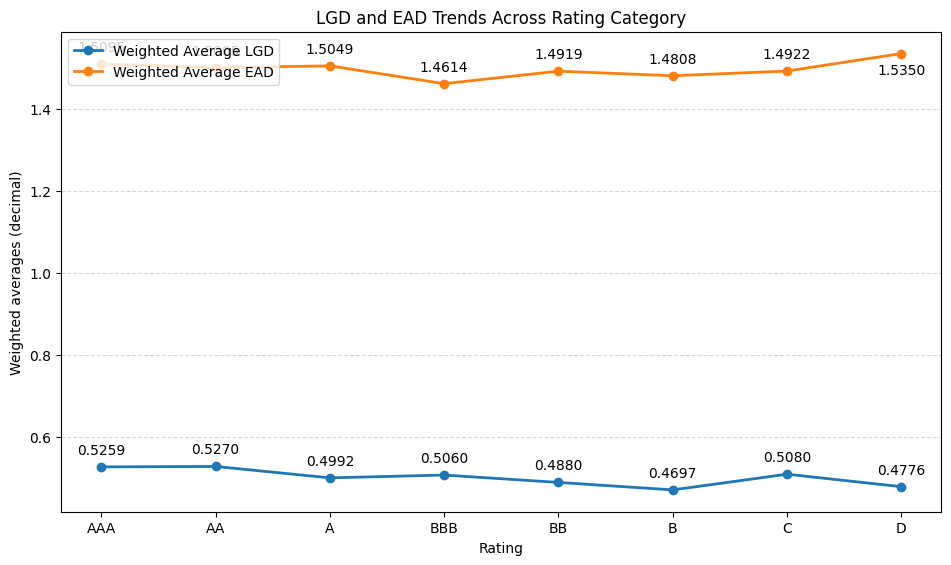

Saved plot to: /content/weighted_lgd_ead_by_rating.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

XLSX = "/content/FRAM-Book.xlsx"
OUT_CSV = "weighted_lgd_ead_by_rating.csv"
OUT_PNG = "weighted_lgd_ead_by_rating.png"

RATING_ORDER = ["AAA", "AA", "A", "BBB", "BB", "B", "C", "D"]

def detect_and_convert_decimal(series, name):
    s_num = pd.to_numeric(series, errors="coerce")
    med = s_num.abs().median(skipna=True)
    if np.isnan(med):
        raise ValueError(f"{name} sheet contains no numeric values.")
    if med > 1.5:
        return s_num / 100.0, "percent"
    else:
        return s_num, "decimal"

df = pd.read_excel(XLSX)

amount_col = "Year 10_Amount in Rs Crore"
ead_col = "Year 10_EAD (As multiple of Amount in Rs Crore) "
lgd_col = "LGD_Year10"
rating_col = "Year 10_Ratings"

amount = pd.to_numeric(df[amount_col], errors="coerce")
lgd_raw = df[lgd_col]
ead_raw = df[ead_col]
rating_clean = df[rating_col].astype(str).str.strip().str.upper().replace({"NAN": np.nan})

merged = pd.DataFrame({
    "Amount": amount,
    "LGD_raw": lgd_raw,
    "EAD_raw": ead_raw,
    "Rating_clean": rating_clean
})

merged = merged[merged["Amount"].notna()].copy()
if merged.empty:
    raise ValueError("No numeric Amount values found after cleaning.")

merged["LGD_decimal"], lgd_detect = detect_and_convert_decimal(merged["LGD_raw"], "LGD")
merged["EAD_decimal"], ead_detect = detect_and_convert_decimal(merged["EAD_raw"], "EAD")

print(f"LGD values detected as: {lgd_detect}; EAD values detected as: {ead_detect}")

merged["Rating_final"] = merged["Rating_clean"]
nonstandard = merged.loc[~merged["Rating_final"].isin(RATING_ORDER), "Rating_final"].astype(str).value_counts()
if not nonstandard.empty:
    print("Non-standard rating labels found (these rows will be ignored for final table):")
    print(nonstandard.to_string())

use = merged.loc[
    merged["Rating_final"].isin(RATING_ORDER) &
    merged["LGD_decimal"].notna() &
    merged["EAD_decimal"].notna()
].copy()

if use.empty:
    raise ValueError("After filtering, no rows left with valid rating + numeric LGD + EAD + amount.")

use["Weighted_LGD_Numerator"] = use["Amount"] * use["LGD_decimal"]
use["Weighted_EAD_Numerator"] = use["Amount"] * use["EAD_decimal"]

agg = use.groupby("Rating_final").agg(
    Total_Exposure_Crores=("Amount", "sum"),
    Weighted_LGD_num=("Weighted_LGD_Numerator", "sum"),
    Weighted_EAD_num=("Weighted_EAD_Numerator", "sum")
)

agg["Weighted_Avg_LGD"] = agg["Weighted_LGD_num"] / agg["Total_Exposure_Crores"]
agg["Weighted_Avg_EAD"] = agg["Weighted_EAD_num"] / agg["Total_Exposure_Crores"]

result = agg.reindex(RATING_ORDER).reset_index().rename(columns={"Rating_final": "Rating"})
result = result[["Rating", "Total_Exposure_Crores", "Weighted_Avg_LGD", "Weighted_Avg_EAD"]]

result.to_csv(OUT_CSV, index=False)
print(f"Saved weighted LGD/EAD by rating to: {os.path.abspath(OUT_CSV)}")
print(result)

labels = result["Rating"].astype(str).tolist()
lgd_vals = result["Weighted_Avg_LGD"].values
ead_vals = result["Weighted_Avg_EAD"].values

fig, ax = plt.subplots(figsize=(10,6))

x = np.arange(len(labels))
ax.plot(x, lgd_vals, marker='o', linewidth=2, label="Weighted Average LGD")
ax.plot(x, ead_vals, marker='o', linewidth=2, label="Weighted Average EAD")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Rating")
ax.set_ylabel("Weighted averages (decimal)")

ymin, ymax = ax.get_ylim()
yrange = ymax - ymin if (ymax - ymin) != 0 else 1
pad = 0.03 * yrange

for i, v in enumerate(lgd_vals):
    if not np.isnan(v):
        y_text = v + 0.02 * yrange
        if y_text > ymax - pad:
            y_text = v - 0.02 * yrange
        ax.text(i, y_text, f"{v:.4f}", ha='center', va='bottom' if y_text>v else 'top')

for i, v in enumerate(ead_vals):
    if not np.isnan(v):
        y_text = v + 0.02 * yrange
        if y_text > ymax - pad:
            y_text = v - 0.02 * yrange
        ax.text(i, y_text, f"{v:.4f}", ha='center', va='bottom' if y_text>v else 'top')

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc="upper left")

plt.title("LGD and EAD Trends Across Rating Category")
plt.subplots_adjust(top=0.92, bottom=0.12, left=0.07, right=0.95)
plt.savefig(OUT_PNG, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved plot to: {os.path.abspath(OUT_PNG)}")


Total Exposure by Rating Category (Year 10)

Available sheets: ['Sheet1']
Using rating column: Year 10_Ratings
Using amount column: Year 10_EAD (As multiple of Amount in Rs Crore) 

Aggregated totals by rating (all labels):
  Rating  Total_Exposure_Crores
0      C             404.540679
1      D             397.017509
2     AA             381.682513
3    AAA             370.390246
4     BB             367.297840
5      A             365.059036
6      B             360.535616
7    BBB             346.624371

Saved CSV: /content/exposure_by_rating_FRAMBook.csv

Final totals (AAA -> D):
  Rating  Total_Exposure_Crores
0    AAA             370.390246
1     AA             381.682513
2      A             365.059036
3    BBB             346.624371
4     BB             367.297840
5      B             360.535616
6      C             404.540679
7      D             397.017509
Saved chart: /content/exposure_by_rating_FRAMBook.png


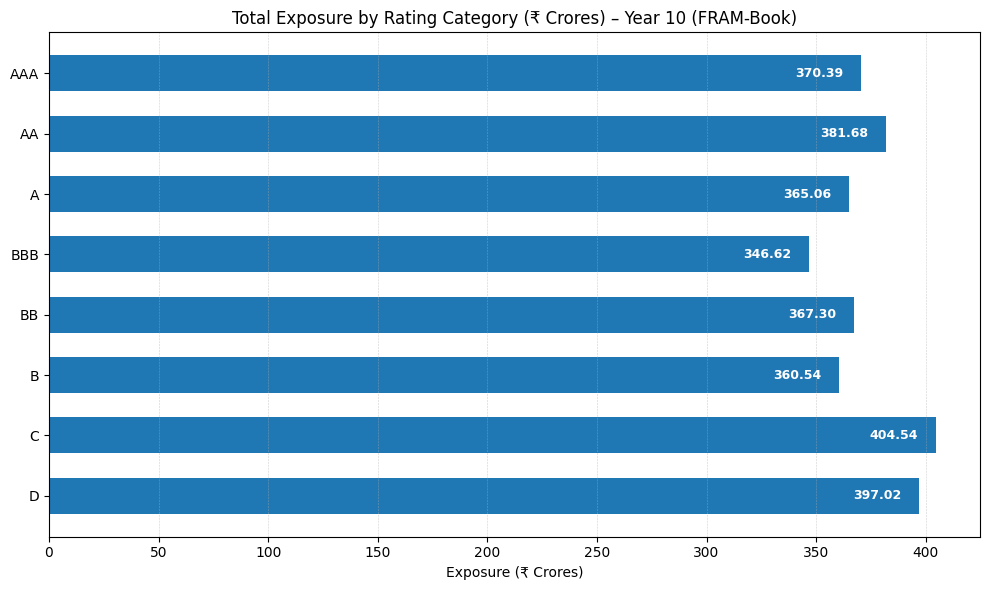

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

xlsx_path = "/content/FRAM-Book.xlsx"

xls = pd.ExcelFile(xlsx_path)
print("Available sheets:", xls.sheet_names)

sheet = xls.sheet_names[0]
df = pd.read_excel(xlsx_path, sheet_name=sheet)

rating_col = None
amount_col = None

for c in df.columns:
    cl = str(c).strip().lower()
    if ("year 10" in cl) and ("rating" in cl):
        rating_col = c
    if ("year 10" in cl) and ("amount" in cl):
        amount_col = c

if rating_col is None:
    raise KeyError("Could not find Year 10 rating column in FRAM-Book.xlsx")
if amount_col is None:
    raise KeyError("Could not find Year 10 amount column in FRAM-Book.xlsx")

print("Using rating column:", rating_col)
print("Using amount column:", amount_col)

df[rating_col] = df[rating_col].astype(str).str.strip()
df[rating_col] = df[rating_col].replace("nan", np.nan)

df[amount_col] = pd.to_numeric(df[amount_col], errors="coerce")

rating_order = ["AAA", "AA", "A", "BBB", "BB", "B", "C", "D"]

valid = df[df[amount_col].notna()].copy()

agg = (
    valid.groupby(valid[rating_col].fillna("UNKNOWN"))[amount_col]
    .sum()
    .reset_index()
)
agg = agg.rename(columns={rating_col: "Rating", amount_col: "Total_Exposure_Crores"})
agg["Rating"] = agg["Rating"].astype(str).str.upper()
agg = agg.sort_values("Total_Exposure_Crores", ascending=False).reset_index(drop=True)

print("\nAggregated totals by rating (all labels):")
print(agg)

final_std = (
    agg.set_index("Rating")
       .reindex(rating_order, fill_value=0)
       .reset_index()
)

out_csv = "exposure_by_rating_FRAMBook.csv"
final_std.to_csv(out_csv, index=False)
print("\nSaved CSV:", os.path.abspath(out_csv))

print("\nFinal totals (AAA -> D):")
print(final_std)

labels = final_std["Rating"]
values = final_std["Total_Exposure_Crores"].values

fig, ax = plt.subplots(figsize=(10, 6))
y_positions = np.arange(len(labels))
ax.barh(y_positions, values, align='center', height=0.6)

ax.set_yticks(y_positions)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Exposure (₹ Crores)")
ax.set_title("Total Exposure by Rating Category (₹ Crores) – Year 10 (FRAM-Book)")

for i, v in enumerate(values):
    label = f"{v:,.2f}"
    max_val = max(values) if len(values) > 0 else 0
    x_pos = v - (0.02 * max_val) if max_val > 0 else v
    if max_val > 0 and x_pos < 0.05 * max_val:
        x_pos = v + 0.01 * max_val
        ax.text(x_pos, i, label, va='center', ha='left', fontsize=9, fontweight='bold')
    else:
        ax.text(x_pos, i, label, va='center', ha='right', color='white', fontsize=9, fontweight='bold')

ax.xaxis.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)
plt.tight_layout()

out_png = "exposure_by_rating_FRAMBook.png"
plt.savefig(out_png, dpi=300)
print("Saved chart:", os.path.abspath(out_png))
plt.show()


2(a): Transition Matrices for Year 2 to 10



In [ ]:
import yfinance as yf
import pandas as pd
import numpy as npx
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from IPython.display import display

warnings.filterwarnings("ignore")

path = Path("/content/FRAM-Book.xlsx")
df = pd.read_excel(path, sheet_name="Sheet1")

df = df.drop(columns=df.columns[11:21])

df.columns = (
    ["Borrower"]
    + [f"Rating Y{i}" for i in range(1, 11)]
    + [f"Amount Y{i}" for i in range(1, 11)]
    + [f"LGD Y{i}" for i in range(1, 11)]
    + [f"EADmult Y{i}" for i in range(1, 11)]
)

for i in range(1, 11):
    df[f"Amount Y{i}"]   = pd.to_numeric(df[f"Amount Y{i}"], errors="coerce")
    df[f"LGD Y{i}"]      = pd.to_numeric(df[f"LGD Y{i}"], errors="coerce")
    df[f"EADmult Y{i}"]  = pd.to_numeric(df[f"EADmult Y{i}"], errors="coerce")

for i in range(1, 11):
    df[f"Rating Y{i}"] = pd.to_numeric(df[f"Rating Y{i}"], errors="coerce").astype("Int64")

ratings = list(range(1, 9))

def build_transition_counts_and_probs(df, from_col, to_col, ratings):
    counts = pd.crosstab(df[from_col], df[to_col]).reindex(
        index=ratings, columns=ratings, fill_value=0
    )
    row_totals = counts.sum(axis=1)
    probs = counts.div(row_totals.replace(0, pd.NA), axis=0).fillna(0)
    return counts, probs

results = {}

for y in range(1, 10):

    from_col   = f"Rating Y{y}"
    to_col     = f"Rating Y{y+1}"
    amount_col = f"Amount Y{y}"
    ead_col    = f"EADmult Y{y}"
    lgd_col    = f"LGD Y{y}"
    exp_col    = f"Exposure Y{y}"

    if exp_col not in df.columns:
        df[exp_col] = df[amount_col] * df[ead_col]

    counts, probs = build_transition_counts_and_probs(df, from_col, to_col, ratings)

    pd_series = probs[8].reindex(ratings).fillna(0)

    exposure_by_rating = (
        df.groupby(from_col)[exp_col]
          .sum()
          .reindex(ratings, fill_value=0)
    )

    num_lgd = ((df[exp_col] * df[lgd_col])
               .groupby(df[from_col])
               .sum()
               .reindex(ratings, fill_value=0))

    lgd_weighted = (
        num_lgd / exposure_by_rating.replace(0, pd.NA)
    ).fillna(0)

    EL_by_rating = pd_series * lgd_weighted * exposure_by_rating

    portfolio_EL = EL_by_rating.sum()

    results[y] = {
        "from_to": f"{y}→{y+1}",
        "counts": counts,
        "probs": probs,
        "pd": pd_series,
        "exposure": exposure_by_rating,
        "lgd_weighted": lgd_weighted,
        "EL_by_rating": EL_by_rating,
        "portfolio_EL": portfolio_EL
    }

for y in range(1, 10):
    print(f"\nYear {y} to Year {y+1} - Transition Matrix\n")
    display(results[y]["counts"])
    print(f"\nYear {y} to Year {y+1} - Transition Probability Matrix\n")
    display(results[y]["probs"])



Year 1 to Year 2 - Transition Matrix



Rating Y2,1,2,3,4,5,6,7,8
Rating Y1,,,,,,,,
1,31,43,22,39,30,35,37,32
2,25,27,28,38,33,53,37,24
3,30,23,22,35,22,26,38,28
4,34,27,30,31,28,30,36,34
5,28,32,28,33,27,27,31,28
6,29,32,28,36,44,31,36,30
7,40,30,26,25,25,29,26,36
8,32,22,30,33,41,39,28,30



Year 1 to Year 2 - Transition Probability Matrix



Rating Y2,1,2,3,4,5,6,7,8
Rating Y1,,,,,,,,
1,0.115242,0.159851,0.081784,0.144981,0.111524,0.130112,0.137546,0.118959
2,0.094340,0.101887,0.105660,0.143396,0.124528,0.200000,0.139623,0.090566
3,0.133929,0.102679,0.098214,0.156250,0.098214,0.116071,0.169643,0.125000
4,0.136000,0.108000,0.120000,0.124000,0.112000,0.120000,0.144000,0.136000
5,0.119658,0.136752,0.119658,0.141026,0.115385,0.115385,0.132479,0.119658
6,0.109023,0.120301,0.105263,0.135338,0.165414,0.116541,0.135338,0.112782
7,0.168776,0.126582,0.109705,0.105485,0.105485,0.122363,0.109705,0.151899
8,0.125490,0.086275,0.117647,0.129412,0.160784,0.152941,0.109804,0.117647



Year 2 to Year 3 - Transition Matrix



...

Rating Y9,1,2,3,4,5,6,7,8
Rating Y8,,,,,,,,
1,0.104603,0.117155,0.133891,0.167364,0.125523,0.121339,0.108787,0.121339
2,0.098859,0.125475,0.117871,0.155894,0.133080,0.129278,0.125475,0.114068
3,0.123506,0.135458,0.115538,0.155378,0.099602,0.091633,0.147410,0.131474
4,0.095238,0.151515,0.151515,0.160173,0.090909,0.108225,0.129870,0.112554
5,0.118143,0.118143,0.130802,0.139241,0.118143,0.109705,0.135021,0.130802
6,0.138889,0.103175,0.150794,0.142857,0.099206,0.126984,0.134921,0.103175
7,0.100386,0.150579,0.115830,0.115830,0.154440,0.135135,0.088803,0.138996
8,0.123134,0.115672,0.123134,0.089552,0.141791,0.138060,0.141791,0.126866



Year 9 to Year 10 - Transition Matrix



Rating Y10,1,2,3,4,5,6,7,8
Rating Y9,,,,,,,,
1,30,28,22,30,30,24,28,34
2,33,41,23,34,28,32,33,30
3,33,33,37,26,25,34,31,40
4,29,38,33,38,27,37,43,35
5,27,28,28,32,35,28,32,32
6,23,36,32,30,31,31,29,29
7,34,27,34,19,41,28,39,31
8,36,24,35,24,29,30,38,29



Year 9 to Year 10 - Transition Probability Matrix



Rating Y10,1,2,3,4,5,6,7,8
Rating Y9,,,,,,,,
1,0.132743,0.123894,0.097345,0.132743,0.132743,0.106195,0.123894,0.150442
2,0.129921,0.161417,0.090551,0.133858,0.110236,0.125984,0.129921,0.118110
3,0.127413,0.127413,0.142857,0.100386,0.096525,0.131274,0.119691,0.154440
4,0.103571,0.135714,0.117857,0.135714,0.096429,0.132143,0.153571,0.125000
5,0.111570,0.115702,0.115702,0.132231,0.144628,0.115702,0.132231,0.132231
6,0.095436,0.149378,0.132780,0.124481,0.128631,0.128631,0.120332,0.120332
7,0.134387,0.106719,0.134387,0.075099,0.162055,0.110672,0.154150,0.122530
8,0.146939,0.097959,0.142857,0.097959,0.118367,0.122449,0.155102,0.118367


2(b): PD for Each Rating + Portfolio PD

In [ ]:
for y in range(1, 10):
    print(f"\nYear {y} to Year {y+1} - PD by Rating and Portfolio PD\n")

    pd_series = results[y]["pd"]
    expo = results[y]["exposure"]
    total_expo = expo.sum()

    if total_expo == 0:
        portfolio_pd = 0
        weights = expo
    else:
        weights = expo / total_expo
        portfolio_pd = (weights * pd_series).sum()

    pd_table = pd.DataFrame({
        "PD": pd_series,
        "Exposure": expo,
        "Weight": weights
    })

    pd_table.loc["Portfolio_PD"] = [portfolio_pd, total_expo, 1.0]

    display(pd_table)
    print(f"Portfolio PD for Year {y} to Year {y+1}: {portfolio_pd:.6f}")



Year 1 to Year 2 - PD by Rating and Portfolio PD



,PD,Exposure,Weight
Rating Y1,,,
1,0.118959,6174.745692,0.137672
2,0.090566,6187.227893,0.137950
3,0.125000,5184.987463,0.115604
4,0.136000,5515.003064,0.122962
5,0.119658,4998.527311,0.111447
6,0.112782,5767.560310,0.128593
7,0.151899,5613.035624,0.125148
8,0.117647,5410.095141,0.120623
Portfolio_PD,0.121084,44851.182497,1.000000


Portfolio PD for Year 1 to Year 2: 0.121084

Year 2 to Year 3 - PD by Rating and Portfolio PD



,PD,Exposure,Weight
Rating Y2,,,
1,0.176707,5763.066782,0.124913
2,0.110169,5432.925506,0.117757
3,0.074766,5013.988560,0.108677
4,0.137037,5958.568480,0.129150
5,0.140000,5520.576981,0.119657
6,0.144444,6525.257885,0.141433
7,0.111524,5993.284169,0.129903
8,0.119835,5929.037248,0.128510
Portfolio_PD,0.127938,46136.705612,1.000000


Portfolio PD for Year 2 to Year 3: 0.127938

Year 3 to Year 4 - PD by Rating and Portfolio PD



...

Portfolio PD for Year 7 to Year 8: 0.134019

Year 8 to Year 9 - PD by Rating and Portfolio PD



,PD,Exposure,Weight
Rating Y8,,,
1,0.121339,5674.272118,0.121444
2,0.114068,6059.546574,0.129690
3,0.131474,6129.765994,0.131193
4,0.112554,5419.519752,0.115992
5,0.130802,5107.340944,0.109310
6,0.103175,5937.501143,0.127078
7,0.138996,5967.472582,0.127720
8,0.126866,6427.828721,0.137572
Portfolio_PD,0.122448,46723.247827,1.000000


Portfolio PD for Year 8 to Year 9: 0.122448

Year 9 to Year 10 - PD by Rating and Portfolio PD



,PD,Exposure,Weight
Rating Y9,,,
1,0.150442,5226.439393,0.113946
2,0.118110,5594.089312,0.121961
3,0.154440,6187.646346,0.134902
4,0.125000,6269.784619,0.136692
5,0.132231,5687.801911,0.124004
6,0.120332,5454.691050,0.118922
7,0.122530,5855.690256,0.127664
8,0.118367,5591.696862,0.121909
Portfolio_PD,0.130248,45867.839748,1.000000


Portfolio PD for Year 9 to Year 10: 0.130248


2(b):PD and EL Trend Analysis

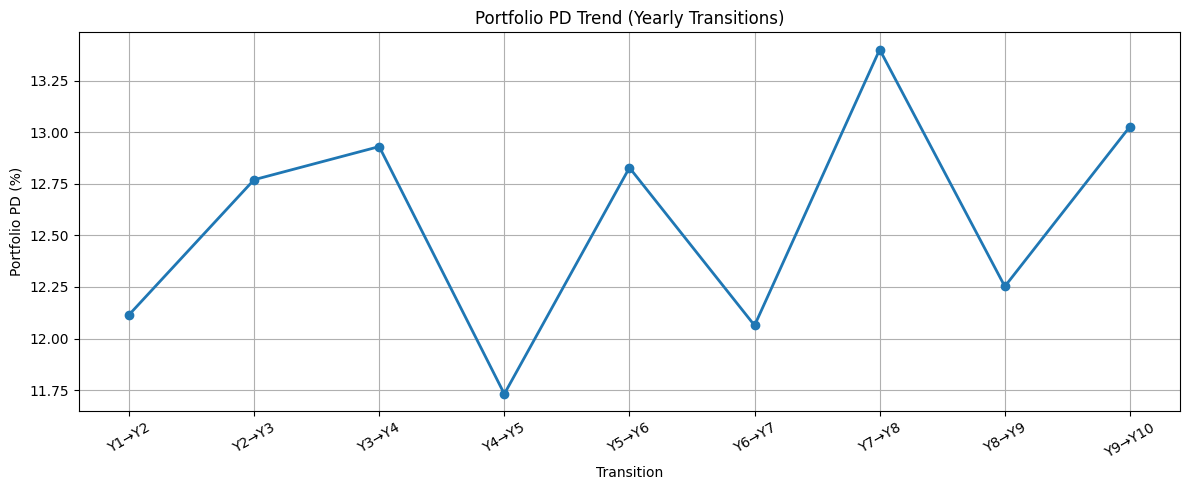

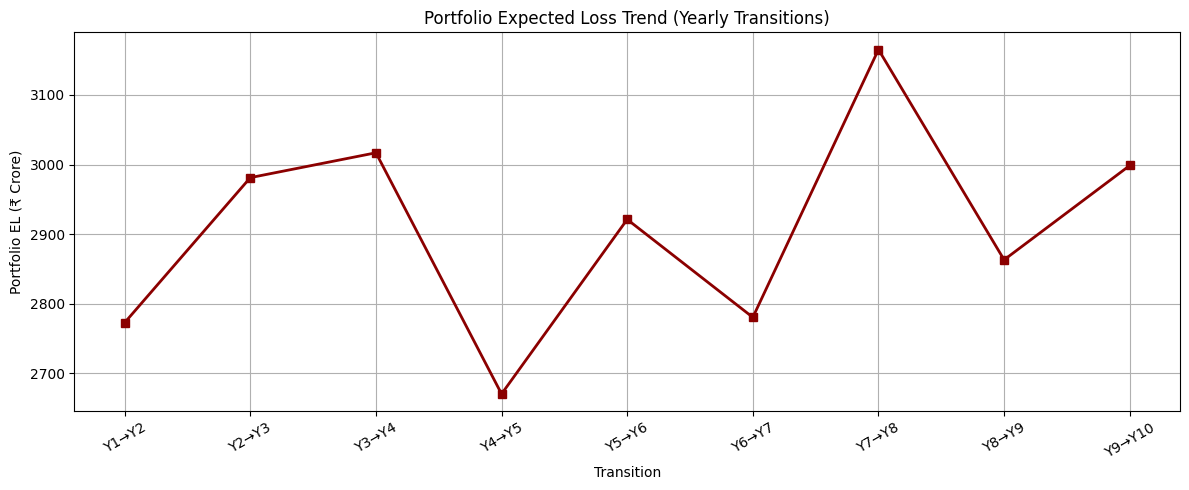

PD Table by Rating and Transition:


,Y1→Y2,Y2→Y3,Y3→Y4,Y4→Y5,Y5→Y6,Y6→Y7,Y7→Y8,Y8→Y9,Y9→Y10
AAA,0.118959,0.176707,0.133891,0.150579,0.109312,0.144033,0.124060,0.121339,0.150442
AA,0.090566,0.110169,0.123016,0.128319,0.136882,0.085502,0.150000,0.114068,0.118110
A,0.125000,0.074766,0.136000,0.120155,0.127490,0.150000,0.111111,0.131474,0.154440
BBB,0.136000,0.137037,0.132812,0.086614,0.129870,0.152091,0.146825,0.112554,0.125000
BB,0.119658,0.140000,0.103053,0.137168,0.152416,0.133065,0.149194,0.130802,0.132231
B,0.112782,0.144444,0.136752,0.090909,0.087649,0.116667,0.150943,0.103175,0.120332
C,0.151899,0.111524,0.131474,0.118110,0.114173,0.080769,0.117871,0.138996,0.122530
D,0.117647,0.119835,0.140625,0.108108,0.170940,0.108949,0.120332,0.126866,0.118367


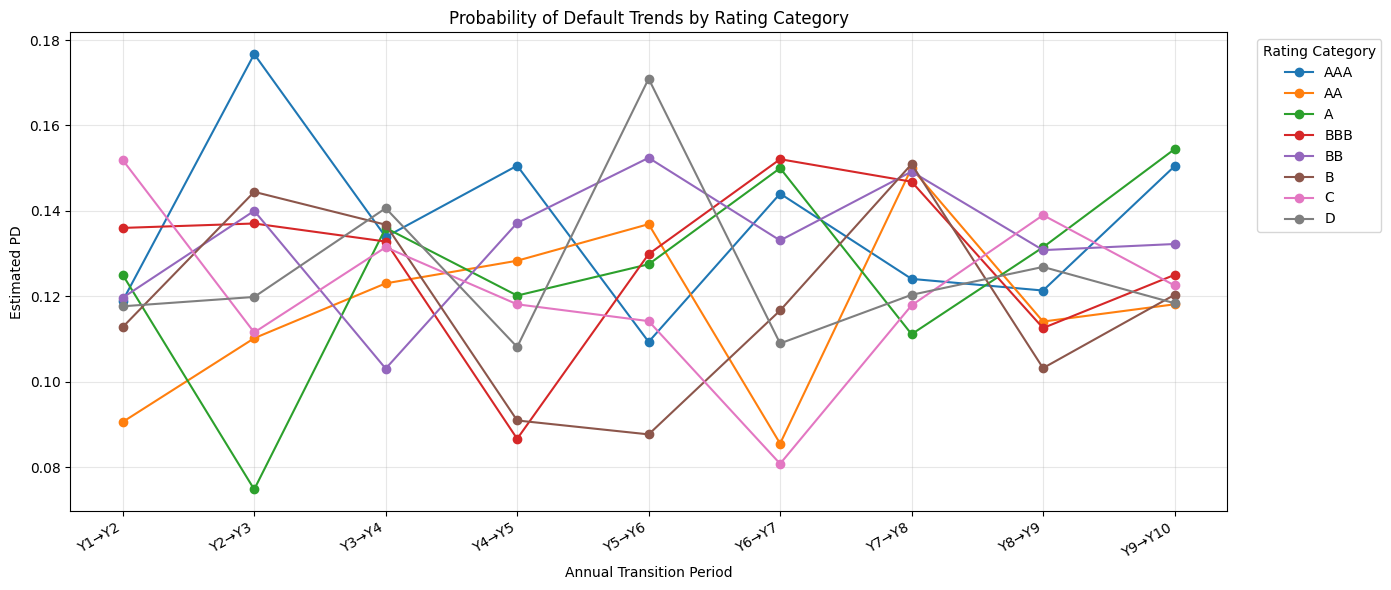

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILEPATH = "/content/FRAM-Book.xlsx"
df = pd.read_excel(FILEPATH)
df.columns = [c.strip() for c in df.columns]

rating_cols = [f"Year {i}_Set" for i in range(1, 11)]
amount_cols = [f"Year {i}_Amount in Rs Crore" for i in range(1, 11)]
ead_cols = [f"Year {i}_EAD (As multiple of Amount in Rs Crore)" for i in range(1, 11)]
lgd_cols = [f"LGD_Year{i}" for i in range(1, 11)]

for c in rating_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")
for c in amount_cols + ead_cols + lgd_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

def build_probs(df, from_col, to_col, ratings=range(1,9)):
    counts = pd.crosstab(df[from_col], df[to_col]).reindex(
        index=ratings, columns=ratings, fill_value=0)
    row_totals = counts.sum(axis=1)
    return counts.div(row_totals.replace(0, np.nan), axis=0).fillna(0)

portfolio_pds = []
portfolio_els = []
pd_by_rating_list = []

transitions = [f"Y{y}→Y{y+1}" for y in range(1,10)]
ratings = list(range(1,9))

for y in range(1, 10):
    r_col = rating_cols[y-1]
    r_next_col = rating_cols[y]
    amt_col = amount_cols[y-1]
    ead_col = ead_cols[y-1]
    lgd_col = lgd_cols[y-1]

    probs = build_probs(df, r_col, r_next_col, ratings)
    pd_by_rating = probs[8].reindex(ratings).fillna(0)
    pd_by_rating_list.append(pd_by_rating)

    df["_EAD_temp"] = df[amt_col] * df[ead_col]
    exposure_by_rating = df.groupby(r_col)["_EAD_temp"].sum().reindex(ratings, fill_value=0)

    amount_by_rating = df.groupby(r_col)[amt_col].sum().reindex(ratings, fill_value=0)
    weights = amount_by_rating / (amount_by_rating.sum() or 1)
    portfolio_pd = (weights * pd_by_rating).sum()
    portfolio_pds.append(portfolio_pd)

    lgd_num = (df["_EAD_temp"] * df[lgd_col]).groupby(df[r_col]).sum().reindex(ratings, fill_value=0)
    lgd_weighted = (lgd_num / exposure_by_rating.replace(0, np.nan)).fillna(0)

    EL_rating = pd_by_rating * lgd_weighted * exposure_by_rating
    portfolio_EL = EL_rating.sum()
    portfolio_els.append(portfolio_EL)

plt.figure(figsize=(12,5))
plt.plot(transitions, np.array(portfolio_pds)*100, marker='o', linewidth=2)
plt.title("Portfolio PD Trend (Yearly Transitions)")
plt.ylabel("Portfolio PD (%)")
plt.xlabel("Transition")
plt.grid(True)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 2) Portfolio EL trend
plt.figure(figsize=(12,5))
plt.plot(transitions, portfolio_els, marker='s', linewidth=2, color='darkred')
plt.title("Portfolio Expected Loss Trend (Yearly Transitions)")
plt.ylabel("Portfolio EL (₹ Crore)")
plt.xlabel("Transition")
plt.grid(True)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

pd_table = pd.DataFrame(index=ratings)
for i, trans in enumerate(transitions):
    pd_table[trans] = pd_by_rating_list[i].reindex(ratings).values

rating_labels = ["AAA","AA","A","BBB","BB","B","C","D"]
label_map = {ratings[i]: rating_labels[i] for i in range(8)}
pd_table.index = [label_map[r] for r in ratings]

print("PD Table by Rating and Transition:")
display(pd_table.style.format("{:.6f}"))

plt.figure(figsize=(14,6))
x = np.arange(len(transitions))
for rating_label in pd_table.index:
    yvals = pd_table.loc[rating_label].values.astype(float)
    plt.plot(x, yvals, marker="o", label=rating_label)

plt.xticks(x, transitions, rotation=30, ha="right")
plt.ylabel("Estimated PD")
plt.xlabel("Annual Transition Period")
plt.title("Probability of Default Trends by Rating Category")
plt.grid(alpha=0.3)
plt.legend(title="Rating Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


2(c): EL for Each Rating + Portfolio EL

In [ ]:
for y in range(1, 10):
    print(f"\nYear {y} to Year {y+1} - EL by Rating and Portfolio EL\n")

    summary = pd.DataFrame({
        "PD": results[y]["pd"],
        "Exposure (EAD)": results[y]["exposure"],
        "LGD (weighted)": results[y]["lgd_weighted"],
        "EL per Rating": results[y]["EL_by_rating"]
    })

    summary.loc["Total"] = [
        "",
        results[y]["exposure"].sum(),
        "",
        results[y]["portfolio_EL"]
    ]

    display(summary)
    print(f"Portfolio EL for Year {y} to Year {y+1}: {results[y]['portfolio_EL']:.4f}")



Year 1 to Year 2 - EL by Rating and Portfolio EL



,PD,Exposure (EAD),LGD (weighted),EL per Rating
Rating Y1,,,,
1,0.118959,6174.745692,0.509296,374.099063
2,0.090566,6187.227893,0.530427,297.226420
3,0.125,5184.987463,0.491424,318.503580
4,0.136,5515.003064,0.500627,375.490665
5,0.119658,4998.527311,0.522851,312.724739
6,0.112782,5767.560310,0.522702,340.005707
7,0.151899,5613.035624,0.501361,427.467018
8,0.117647,5410.095141,0.514528,327.488015
Total,,44851.182497,,2773.005208


Portfolio EL for Year 1 to Year 2: 2773.0052

Year 2 to Year 3 - EL by Rating and Portfolio EL



,PD,Exposure (EAD),LGD (weighted),EL per Rating
Rating Y2,,,,
1,0.176707,5763.066782,0.483272,492.150851
2,0.110169,5432.925506,0.491861,294.400038
3,0.074766,5013.988560,0.504984,189.307183
4,0.137037,5958.568480,0.509061,415.671114
5,0.14,5520.576981,0.503131,388.860208
6,0.144444,6525.257885,0.533651,502.985604
7,0.111524,5993.284169,0.492445,329.148144
8,0.119835,5929.037248,0.518989,368.744341
Total,,46136.705612,,2981.267482


Portfolio EL for Year 2 to Year 3: 2981.2675

Year 3 to Year 4 - EL by Rating and Portfolio EL



...

Portfolio EL for Year 7 to Year 8: 3165.2028

Year 8 to Year 9 - EL by Rating and Portfolio EL



,PD,Exposure (EAD),LGD (weighted),EL per Rating
Rating Y8,,,,
1,0.121339,5674.272118,0.492625,339.177045
2,0.114068,6059.546574,0.501205,346.434449
3,0.131474,6129.765994,0.502019,404.579943
4,0.112554,5419.519752,0.502522,306.532783
5,0.130802,5107.340944,0.520987,348.044813
6,0.103175,5937.501143,0.507368,310.813343
7,0.138996,5967.472582,0.476276,395.049602
8,0.126866,6427.828721,0.505978,412.610574
Total,,46723.247827,,2863.242551


Portfolio EL for Year 8 to Year 9: 2863.2426

Year 9 to Year 10 - EL by Rating and Portfolio EL



,PD,Exposure (EAD),LGD (weighted),EL per Rating
Rating Y9,,,,
1,0.150442,5226.439393,0.500639,393.641415
2,0.11811,5594.089312,0.498081,329.091935
3,0.15444,6187.646346,0.509256,486.655817
4,0.125,6269.784619,0.5176,405.654854
5,0.132231,5687.801911,0.485575,365.203613
6,0.120332,5454.691050,0.486944,319.616999
7,0.12253,5855.690256,0.517154,371.055720
8,0.118367,5591.696862,0.495227,327.777936
Total,,45867.839748,,2998.698288


Portfolio EL for Year 9 to Year 10: 2998.6983


3: Cumulative Probability of Default (CPD) – 5th Year & 10th Year

In [ ]:
def multiply_seq(mats):
    M = mats[0].copy()
    for mat in mats[1:]:
        M = M @ mat
    return M

ratings = list(range(1, 9))

P_list = []
for y in range(1, 10):
    P_list.append(
        results[y]["probs"]
        .reindex(index=ratings, columns=ratings, fill_value=0)
        .values
    )

P5  = multiply_seq(P_list[0:5])
P10 = multiply_seq(P_list[0:9])

CPD5_array  = P5[:, 7]
CPD10_array = P10[:, 7]

CPD5  = pd.Series(CPD5_array,  index=ratings, name="5yr_CPD")
CPD10 = pd.Series(CPD10_array, index=ratings, name="10yr_CPD")

base_year = 1
expo = results[base_year]["exposure"].reindex(ratings).fillna(0)
total_expo = expo.sum()

weights = expo / total_expo

portfolio_CPD_5  = (weights * CPD5).sum()
portfolio_CPD_10 = (weights * CPD10).sum()

cpd_table = pd.DataFrame({
    "5yr_CPD":  CPD5,
    "10yr_CPD": CPD10,
    "Exposure": expo,
    "Weight":   weights
})
cpd_table.loc["Portfolio_Total"] = [portfolio_CPD_5, portfolio_CPD_10, total_expo, 1.0]

display(
    cpd_table.style.format({
        "5yr_CPD": "{:.6f}",
        "10yr_CPD": "{:.6f}",
        "Exposure": "{:,.2f}",
        "Weight": "{:.4f}"
    })
)

print(f"\nPortfolio 5-year CPD : {portfolio_CPD_5:.6f}")
print(f"Portfolio 10-year CPD: {portfolio_CPD_10:.6f}")


,5yr_CPD,10yr_CPD,Exposure,Weight
1,0.128500,0.130000,"6,174.75",0.1377
2,0.128500,0.130000,"6,187.23",0.1380
3,0.128500,0.130000,"5,184.99",0.1156
4,0.128500,0.130000,"5,515.00",0.1230
5,0.128500,0.130000,"4,998.53",0.1114
6,0.128500,0.130000,"5,767.56",0.1286
7,0.128500,0.130000,"5,613.04",0.1251
8,0.128500,0.130000,"5,410.10",0.1206
Portfolio_Total,0.128500,0.130000,"44,851.18",1.0000



Portfolio 5-year CPD : 0.128500
Portfolio 10-year CPD: 0.130000


5(a):Stress test case 1

Detected EAD Columns: ['Year 1_EAD (As multiple of Amount in Rs Crore)', 'Year 2_EAD (As multiple of Amount in Rs Crore)', 'Year 3_EAD (As multiple of Amount in Rs Crore)', 'Year 4_EAD (As multiple of Amount in Rs Crore)', 'Year 5_EAD (As multiple of Amount in Rs Crore)', 'Year 6_EAD (As multiple of Amount in Rs Crore)', 'Year 7_EAD (As multiple of Amount in Rs Crore)', 'Year 8_EAD (As multiple of Amount in Rs Crore)', 'Year 9_EAD (As multiple of Amount in Rs Crore)', 'Year 10_EAD (As multiple of Amount in Rs Crore)']
===== YEAR-WISE EXPECTED LOSS COMPARISON =====
   Year  Baseline EL  Adjusted EL  % Increase Due to LGD Scaling
0     1     0.000000     0.000000                            NaN
1     2  2820.186451  3457.840718                      22.610359
2     3  2984.172944  3772.698999                      26.423604
3     4  2933.189442  3833.910238                      30.707897
4     5  2647.742990  3682.638472                      39.085949
5     6  2956.422949  3695.092319      

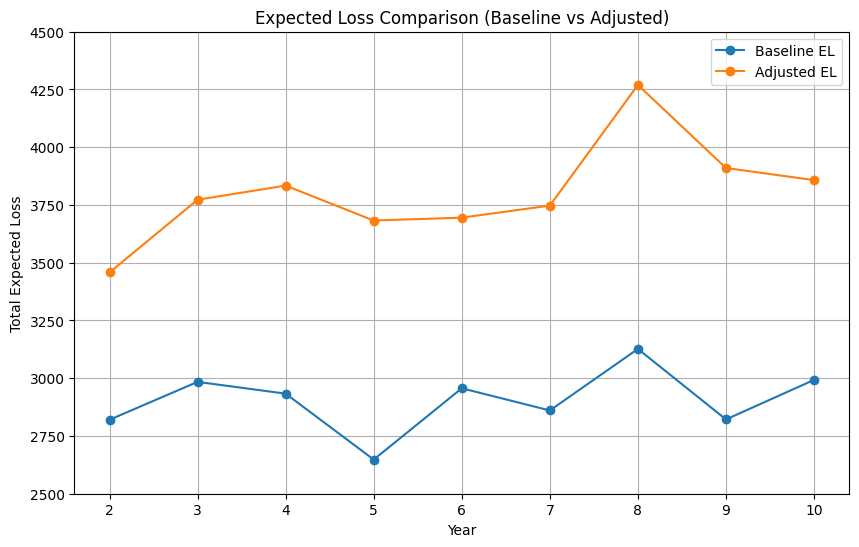

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("/content/FRAM-Book.xlsx")

df.columns = df.columns.str.strip()

rating_cols = [f"Year {i}_Ratings" for i in range(1, 11)]
amt_cols = [f"Year {i}_Amount in Rs Crore" for i in range(1, 11)]
lgd_cols = [f"LGD_Year{i}" for i in range(1, 11)]

ead_cols = [col for col in df.columns if "_EAD" in col]
print("Detected EAD Columns:", ead_cols)

ratings_order = ["AAA", "AA", "A", "BBB", "BB", "B", "C", "D"]

for col in rating_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace("nan", np.nan)

df[lgd_cols] = df[lgd_cols].apply(pd.to_numeric, errors="coerce")
df[amt_cols] = df[amt_cols].apply(pd.to_numeric, errors="coerce")
df[ead_cols] = df[ead_cols].apply(pd.to_numeric, errors="coerce")

pd_probs = {}

for t in range(1, 10):
    start = f"Year {t}_Ratings"
    end = f"Year {t+1}_Ratings"
    tm_counts = pd.crosstab(df[start], df[end])
    tm = tm_counts.reindex(index=ratings_order, columns=ratings_order).fillna(0.0)
    tm_prob = tm.div(tm.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    pd_probs[t] = tm_prob["D"].reindex(ratings_order).fillna(0)

PD_for_Year = pd.DataFrame(index=df.index)
PD_for_Year["PD_Year1"] = 0

for year in range(2, 11):
    prev = year - 1
    PD_for_Year[f"PD_Year{year}"] = df[f"Year {prev}_Ratings"].map(pd_probs[prev]).fillna(0)

EAD_amt = pd.DataFrame(index=df.index)

for y in range(1, 11):
    amt_col = f"Year {y}_Amount in Rs Crore"
    matching_ead = [c for c in ead_cols if f"{y}_" in c]
    if not matching_ead:
        continue
    ead_col = matching_ead[0]
    EAD_amt[f"EAD_Year{y}"] = df[amt_col] * df[ead_col]

el_cols = []

for y in range(1, 11):
    pd_col = f"PD_Year{y}"
    lgd_col = f"LGD_Year{y}"
    ead_col = f"EAD_Year{y}"
    el_col = f"EL_Year{y}"
    df[el_col] = PD_for_Year[pd_col] * df[lgd_col] * EAD_amt[ead_col]
    el_cols.append(el_col)

df["Total_EL"] = df[el_cols].sum(axis=1)
baseline_yearwise = df[el_cols].sum()

factors = [1.49,1.24,1.29,1.35,1.49,1.27,1.36,1.45,1.48,1.33]

for col, factor in zip(lgd_cols, factors):
    df[col] = df[col] * factor
    df[col] = df[col].clip(upper=1)

adjusted_el = []

for y in range(1, 11):
    adjusted_el.append((PD_for_Year[f"PD_Year{y}"] * df[f"LGD_Year{y}"] * EAD_amt[f"EAD_Year{y}"]).sum())

adj_series = pd.Series(adjusted_el, index=range(1, 11))

comparison = pd.DataFrame({
    "Year": range(1, 11),
    "Baseline EL": baseline_yearwise.values,
    "Adjusted EL": adj_series.values,
})

comparison["% Increase Due to LGD Scaling"] = (
    (comparison["Adjusted EL"] - comparison["Baseline EL"]) /
    comparison["Baseline EL"] * 100
)

print("===== YEAR-WISE EXPECTED LOSS COMPARISON =====")
print(comparison)

comparison_filtered = comparison[comparison["Year"] >= 2]

plt.figure(figsize=(10,6))
plt.plot(comparison_filtered["Year"], comparison_filtered["Baseline EL"], marker="o", label="Baseline EL")
plt.plot(comparison_filtered["Year"], comparison_filtered["Adjusted EL"], marker="o", label="Adjusted EL")
plt.title("Expected Loss Comparison (Baseline vs Adjusted)")
plt.xlabel("Year")
plt.ylabel("Total Expected Loss")
plt.legend()
plt.grid(True)
plt.ylim(2500, 4500)
plt.show()


5(a):Stress test case 2(Slippage)

Detected EAD Columns: ['Year 1_EAD (As multiple of Amount in Rs Crore)', 'Year 2_EAD (As multiple of Amount in Rs Crore)', 'Year 3_EAD (As multiple of Amount in Rs Crore)', 'Year 4_EAD (As multiple of Amount in Rs Crore)', 'Year 5_EAD (As multiple of Amount in Rs Crore)', 'Year 6_EAD (As multiple of Amount in Rs Crore)', 'Year 7_EAD (As multiple of Amount in Rs Crore)', 'Year 8_EAD (As multiple of Amount in Rs Crore)', 'Year 9_EAD (As multiple of Amount in Rs Crore)', 'Year 10_EAD (As multiple of Amount in Rs Crore)']

===== EXPECTED LOSS BY RATING CATEGORY (YEAR 10) =====
                Total EL (Normal)  Total EL (Slippage)     Change   % Change
Year 9_Ratings                                                              
AAA                    378.004083           296.765595 -81.238487 -21.491431
AA                     324.125073           343.032369  18.907296   5.833333
A                      446.370533           347.789323 -98.581210 -22.085062
BBB                    455.642198  

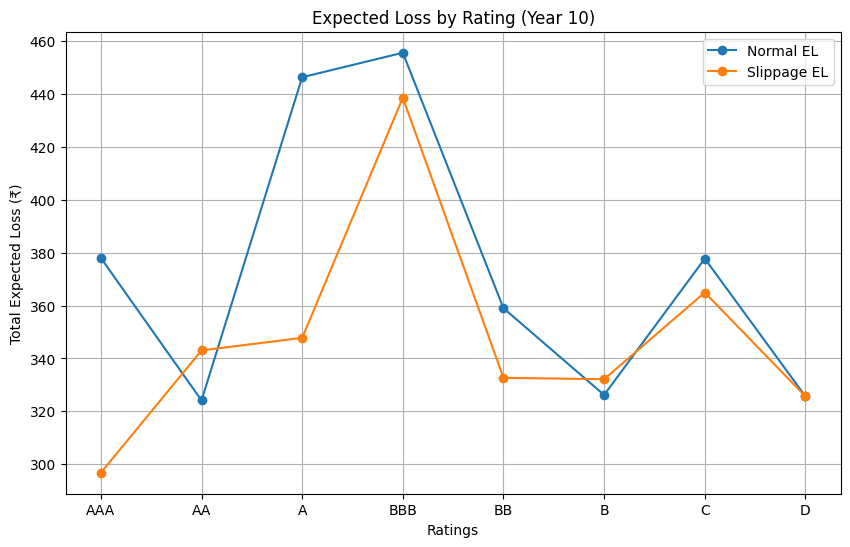

In [ ]:
# Stress Case 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("/content/FRAM-Book.xlsx")

df.columns = df.columns.str.strip()

ratings_order = ["AAA","AA","A","BBB","BB","B","C","D"]
rating_cols = [f"Year {i}_Ratings" for i in range(1, 11)]
amt_cols = [f"Year {i}_Amount in Rs Crore" for i in range(1, 11)]
lgd_cols = [f"LGD_Year{i}" for i in range(1, 11)]

ead_cols = [col for col in df.columns if "_EAD" in col]
print("Detected EAD Columns:", ead_cols)

for col in rating_cols:
    df[col] = df[col].astype(str).str.strip().replace("nan", np.nan)

df[amt_cols] = df[amt_cols].apply(pd.to_numeric, errors="coerce")
df[lgd_cols] = df[lgd_cols].apply(pd.to_numeric, errors="coerce")
df[ead_cols] = df[ead_cols].apply(pd.to_numeric, errors="coerce")

pd_probs = {}

for t in range(1, 10):
    tm = pd.crosstab(df[f"Year {t}_Ratings"], df[f"Year {t+1}_Ratings"])
    tm = tm.reindex(index=ratings_order, columns=ratings_order).fillna(0)
    tm_prob = tm.div(tm.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
    pd_probs[t] = tm_prob["D"].reindex(ratings_order).fillna(0)

df["PD_Y10_normal"] = df["Year 9_Ratings"].map(pd_probs[9]).fillna(0)

slip_map = {
    "AAA": "AA",
    "AA": "BBB",
    "A": "B",
    "BBB": "B",
    "BB": "C",
    "B": "C",
    "C": "D",
    "D": "D"
}

df["Year9_Slipped"] = df["Year 9_Ratings"].map(slip_map)
df["PD_Y10_slip"] = df["Year9_Slipped"].map(pd_probs[9]).fillna(0)

ead10 = [c for c in ead_cols if "10" in c][0]
df["EAD_Y10"] = df["Year 10_Amount in Rs Crore"] * df[ead10]

df["LGD_Y10_used"] = df["LGD_Year10"]

df["EL_Y10_normal"] = df["PD_Y10_normal"] * df["LGD_Y10_used"] * df["EAD_Y10"]
df["EL_Y10_slip"] = df["PD_Y10_slip"] * df["LGD_Y10_used"] * df["EAD_Y10"]

summary = pd.DataFrame({
    "Total EL (Normal)": df.groupby("Year 9_Ratings")["EL_Y10_normal"].sum().reindex(ratings_order),
    "Total EL (Slippage)": df.groupby("Year 9_Ratings")["EL_Y10_slip"].sum().reindex(ratings_order)
})

summary["Change"] = summary["Total EL (Slippage)"] - summary["Total EL (Normal)"]
summary["% Change"] = (summary["Change"] / summary["Total EL (Normal)"]) * 100

print("\n===== EXPECTED LOSS BY RATING CATEGORY (YEAR 10) =====")
print(summary)

plt.figure(figsize=(10,6))
plt.plot(summary.index, summary["Total EL (Normal)"], marker="o", label="Normal EL")
plt.plot(summary.index, summary["Total EL (Slippage)"], marker="o", label="Slippage EL")
plt.title("Expected Loss by Rating (Year 10)")
plt.xlabel("Ratings")
plt.ylabel("Total Expected Loss (₹)")
plt.grid(True)
plt.legend()
plt.show()


6(a):Rating Stability

     avg_stay  std_stay  stability_score
AA   0.131406  0.022724         0.128487
B    0.130330  0.021046         0.127643
C    0.129422  0.019833         0.126905
BBB  0.126163  0.020523         0.123626
D    0.125741  0.019502         0.123336
BB   0.120976  0.017154         0.118935
AAA  0.120549  0.019050         0.118295
A    0.117013  0.026843         0.113955


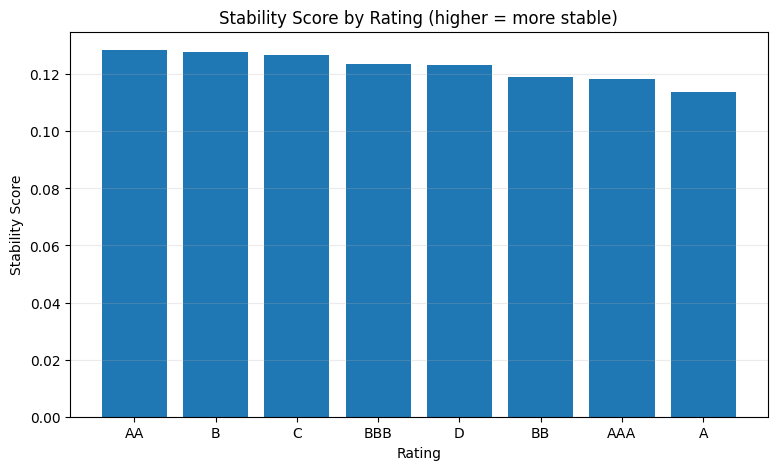

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILEPATH = "/content/FRAM-Book.xlsx"
df = pd.read_excel(FILEPATH)
df.columns = [c.strip() if isinstance(c, str) else c for c in df.columns]

rating_cols = [f"Year {i}_Set" for i in range(1, 11)]
ratings = list(range(1,9))

def build_probs(df, from_col, to_col, ratings=range(1,9)):
    counts = pd.crosstab(df[from_col], df[to_col]).reindex(index=ratings, columns=ratings, fill_value=0)
    row_totals = counts.sum(axis=1)
    return counts.div(row_totals.replace(0, np.nan), axis=0).fillna(0)

diag_matrix = pd.DataFrame(index=ratings, columns=[f"Y{y}→Y{y+1}" for y in range(1,10)], dtype=float)

for y in range(1, 10):
    probs = build_probs(df, f"Year {y}_Set", f"Year {y+1}_Set", ratings)
    for r in ratings:
        diag_matrix.at[r, f"Y{y}→Y{y+1}"] = probs.at[r, r] if (r in probs.index and r in probs.columns) else 0.0

stats = pd.DataFrame(index=ratings)
stats["avg_stay"] = diag_matrix.mean(axis=1)
stats["std_stay"] = diag_matrix.std(axis=1)
stats["stability_score"] = stats["avg_stay"] / (1.0 + stats["std_stay"])

label_map = {1:"AAA",2:"AA",3:"A",4:"BBB",5:"BB",6:"B",7:"C",8:"D"}
stats.index = [label_map[i] for i in stats.index]

stats_sorted = stats.sort_values("stability_score", ascending=False)
print(stats_sorted)

plt.figure(figsize=(9,5))
plt.bar(stats_sorted.index, stats_sorted["stability_score"])
plt.title("Stability Score by Rating (higher = more stable)")
plt.xlabel("Rating")
plt.ylabel("Stability Score")
plt.grid(alpha=0.25, axis='y')
plt.show()


6(b):Chi-square Migration Shift Test


Chi-square statistics for rating migration shifts:


,Comparison,Chi-square
0,Y1→Y2 vs Y2→Y3,155.62
1,Y2→Y3 vs Y3→Y4,129.26
2,Y3→Y4 vs Y4→Y5,120.81
3,Y4→Y5 vs Y5→Y6,119.97
4,Y5→Y6 vs Y6→Y7,114.69
5,Y6→Y7 vs Y7→Y8,92.67
6,Y7→Y8 vs Y8→Y9,102.63
7,Y8→Y9 vs Y9→Y10,91.07


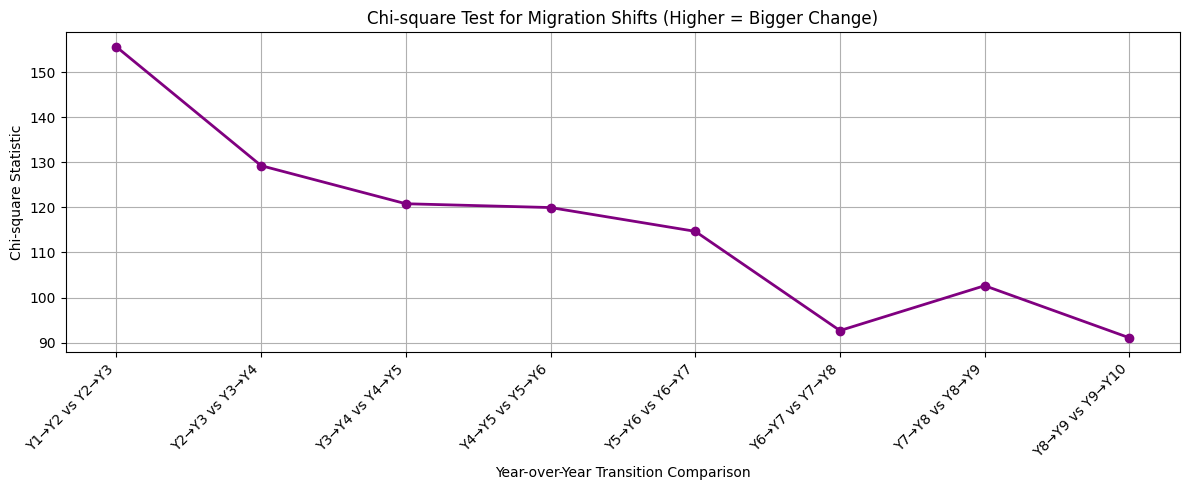

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare

FILEPATH = "/content/FRAM-Book.xlsx"
df = pd.read_excel(FILEPATH)
df.columns = [c.strip() for c in df.columns]

rating_cols = [f"Year {i}_Set" for i in range(1, 11)]
ratings = list(range(1,9))

def build_counts(df, from_col, to_col):
    return (pd.crosstab(df[from_col], df[to_col])
              .reindex(index=ratings, columns=ratings, fill_value=0))

count_matrices = {}
for y in range(1, 10):
    count_matrices[f"Y{y}→Y{y+1}"] = build_counts(
        df, f"Year {y}_Set", f"Year {y+1}_Set"
    )

chi_values = []
years = []

keys = list(count_matrices.keys())

for i in range(1, len(keys)):
    k_prev = keys[i-1]
    k_curr = keys[i]

    C1 = count_matrices[k_prev].values.flatten()
    C2 = count_matrices[k_curr].values.flatten()

    C1 = C1 + 1
    C2 = C2 + 1

    chi_stat, p_val = chisquare(C1, C2)

    chi_values.append(chi_stat)
    years.append(f"{k_prev} vs {k_curr}")

result = pd.DataFrame({
    "Comparison": years,
    "Chi-square": chi_values
})

print("\nChi-square statistics for rating migration shifts:")
display(result.style.format({"Chi-square": "{:.2f}"}))

plt.figure(figsize=(12,5))
plt.plot(years, chi_values, marker='o', linewidth=2, color='purple')
plt.title("Chi-square Test for Migration Shifts (Higher = Bigger Change)")
plt.ylabel("Chi-square Statistic")
plt.xlabel("Year-over-Year Transition Comparison")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()
